# Classical Decomposition - Start

# 1. Generate a Synthetic Time Series Dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Let's create a dataset with a clear trend, seasonality, and some noise.
np.random.seed(42)
n_points = 120  # 10 years of monthly data
index = pd.date_range(start='2015-01-01', periods=n_points, freq='MS') # Monthly Start

# Trend: Linear increase
trend = np.linspace(0, 20, n_points)

# Seasonality: Monthly pattern (e.g., higher sales in certain months)
# Let's create a 12-month cycle
seasonal_pattern = np.array([2, 3, 4, 5, 6, 7, 6, 5, 4, 3, 2, 1])
seasonality = np.tile(seasonal_pattern, n_points // 12)

# Residuals: Random noise
residuals = np.random.normal(0, 1.5, n_points)


# Combine them using an Additive Model for this example

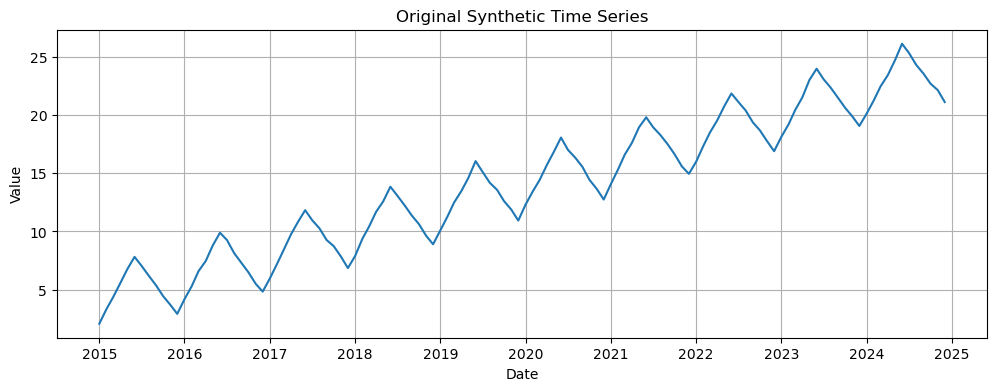

In [31]:
# Combine them using an Additive Model for this example
time_series = trend + seasonality + residuals

# Create a Pandas Series
data = pd.Series(time_series, index=index)

# Plot the original time series
plt.figure(figsize=(12, 4))
plt.plot(data)
plt.title('Original Synthetic Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

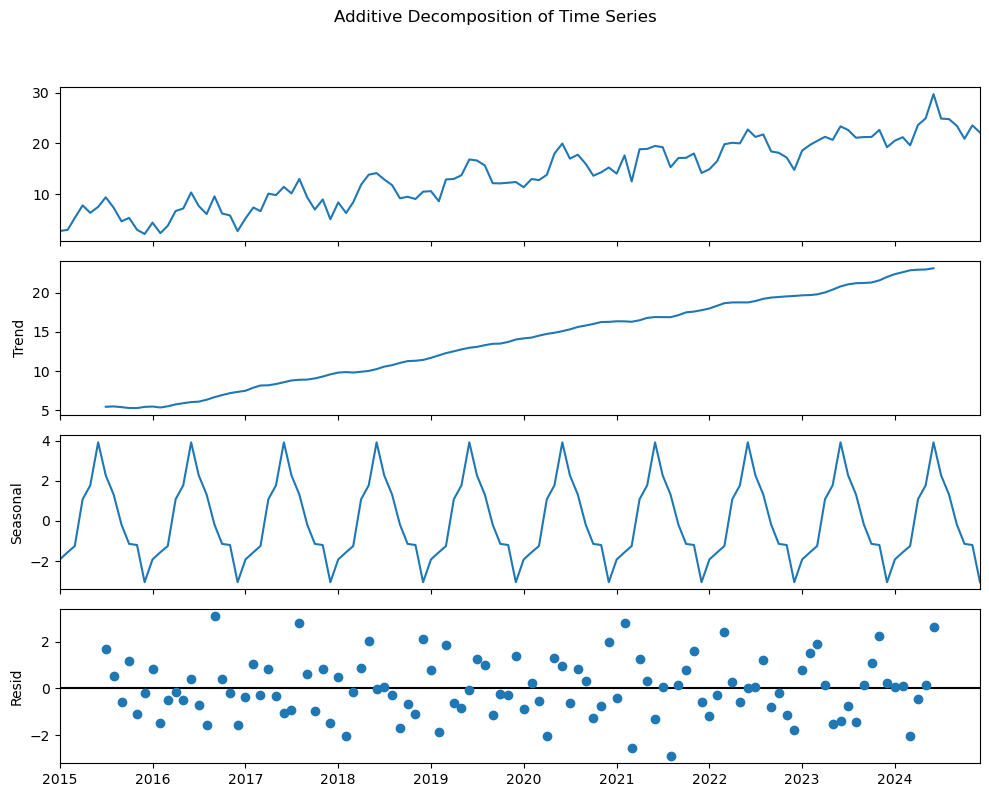

In [23]:
# Perform Classical Decomposition (Additive Model)
# The `period` argument is crucial for seasonality. For monthly data, it's 12.
decomposition_additive = seasonal_decompose(data, model='additive', period=12)

# Plot the decomposed components
fig_additive = decomposition_additive.plot()
fig_additive.set_size_inches(10, 8)
fig_additive.suptitle('Additive Decomposition of Time Series', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# You can access the components individually:
trend_component_add = decomposition_additive.trend
seasonal_component_add = decomposition_additive.seasonal
residual_component_add = decomposition_additive.resid

# print("\nAdditive Model Components (first 5 values):")
# print("Original Data:\n", data.head())
# print("Trend Component:\n", trend_component_add.head())
# print("Seasonal Component:\n", seasonal_component_add.head())
# print("Residual Component:\n", residual_component_add.head())



# Combine them using an Multiplicative Model for this example

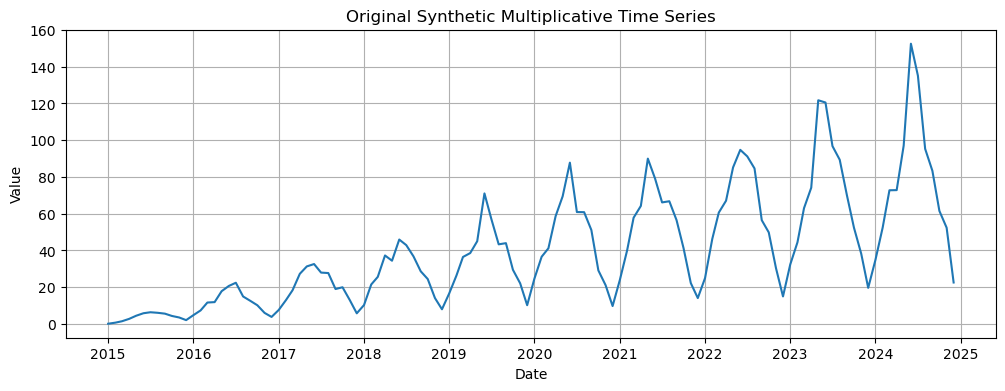

In [30]:
# Combine them using an Multiplicative Model for this example
# Let's create a time series where seasonality grows with the trend

# Here we are talking very small noice
residuals = np.random.normal(0.01, 0.1, n_points)

residual_multiplier = 1 + residuals
residual_multiplier[residual_multiplier <= 0] = 0.01 # Clip any values <= 0 to a small positive number

time_series_multiplicative = trend * seasonality * residual_multiplier # Scale residuals for multiplicative effect
data_multiplicative = pd.Series(time_series_multiplicative, index=index)
data_multiplicative = data_multiplicative + 0.1

plt.figure(figsize=(12, 4))
plt.plot(data_multiplicative)
plt.title('Original Synthetic Multiplicative Time Series')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()


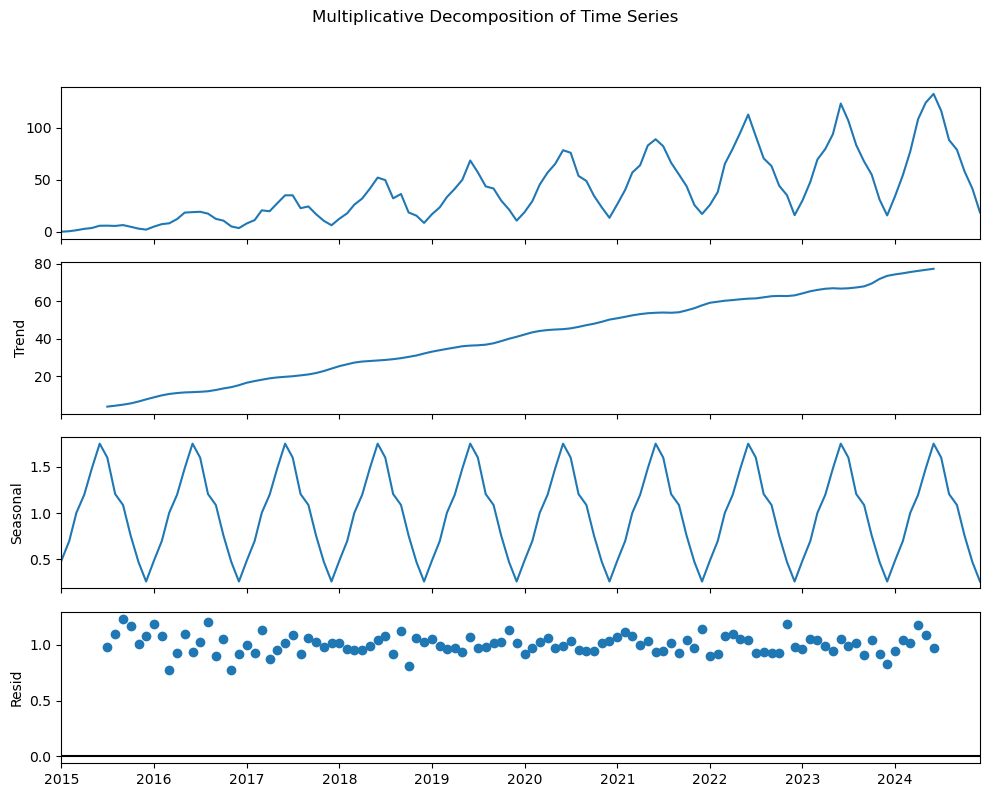

In [29]:
# Perform Classical Decomposition (Multiplicative Model)
decomposition_multiplicative = seasonal_decompose(data_multiplicative, model='multiplicative', period=12)

# Plot the decomposed components
fig_multiplicative = decomposition_multiplicative.plot()
fig_multiplicative.set_size_inches(10, 8)
fig_multiplicative.suptitle('Multiplicative Decomposition of Time Series', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# print("\nMultiplicative Model Components (first 5 values):")
# print("Original Data Multiplicative:\n", data_multiplicative.head())
# print("Trend Component:\n", decomposition_multiplicative.trend.head())
# print("Seasonal Component:\n", decomposition_multiplicative.seasonal.head())
# print("Residual Component:\n", decomposition_multiplicative.resid.head())

# Classical Decomposition - End

# ======================================================

# STL Decomposition - Start

In [ ]:
# Seasonal Trend Decompositions using LOESS Method
# LOESS:- Locally Estimated Scatterplot Smoothing

Seasonal-Trend Decomposition using LOESS (STL)

STL (Seasonal-Trend Decomposition using LOESS) is a powerful and versatile method for decomposing a time series into three components: seasonal, trend, and residual (remainder). It was developed by R.B. Cleveland, W.S. Cleveland, J.E. McRae, and I. Terpenning in 1990.

Unlike classical decomposition methods, STL has several advantages:

    Robustness to Outliers: STL is robust to outliers in the data. LOESS (Locally Estimated Scatterplot Smoothing) is a non-parametric regression method that uses local fitting of polynomials. This local fitting makes it less sensitive to extreme values, meaning outliers don't unduly distort the trend or seasonal components.

    Handles Any Type of Seasonality: It can handle various types of seasonal components, including those that change over time (e.g., evolving seasonal patterns).

    User-Defined Parameters: It allows for user control over the smoothness of the trend and seasonal components through various parameters, offering flexibility in how the decomposition is performed.

    No Assumption of Additive or Multiplicative Model: STL works by iteratively applying LOESS. It can implicitly handle both additive and multiplicative relationships by taking logarithms of the series if a multiplicative model is more appropriate, or by working directly with the original series for an additive model. statsmodels handles this automatically via the robust parameter.

    Decomposition of Seasonal and Trend: It performs separate smoothing operations for the seasonal and trend components, which can be beneficial for specific analyses.
-----------------------------------------------------------------------------------------------------------
How STL Works (Simplified Overview):

STL iteratively refines the seasonal and trend components. The core idea is:

    Detrending: Subtract an initial trend estimate from the original series to get a detrended series.

    Seasonal Sub-series Smoothing: For each period (e.g., January data points across all years, February data points across all years), smooth the detrended series using LOESS to estimate the seasonal component for that period.

    Deseasonalizing: Subtract the estimated seasonal component from the original series to get a deseasonalized series.

    Trend Smoothing: Smooth the deseasonalized series using LOESS to estimate the trend component.

    Residual Calculation: The remainder is what's left after subtracting the seasonal and trend components from the original series.

    Iteration: Steps 1-5 are repeated for several passes, with weights adjusted for robustness, leading to refined estimates of the components.
-----------------------------------------------------------------------------------------------------------
When to Use STL:

    When your time series might contain outliers.

    When the seasonal pattern might change over time.

    When you need more control over the smoothness of the trend and seasonal components.

    When you want a more flexible and robust decomposition than classical methods.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL

# 1. Generate a Synthetic Time Series Dataset with Outliers and Evolving Seasonality
np.random.seed(42)
n_points = 180  # 15 years of monthly data
index = pd.date_range(start='2010-01-01', periods=n_points, freq='MS')

# Trend: Linear increase with some curvature
trend_base = np.linspace(0, 30, n_points)
trend = trend_base + np.sin(np.linspace(0, 2*np.pi, n_points) * 0.5) * 5

# Seasonality: Monthly pattern that slightly changes over time
# Let's make the seasonal amplitude grow slightly
base_seasonal_pattern = np.array([2, 3, 4, 5, 6, 7, 6, 5, 4, 3, 2, 1])
seasonal_multiplier = np.linspace(0.8, 1.2, n_points // 12).repeat(12)[:n_points] # Seasonal amplitude changes
seasonality = np.tile(base_seasonal_pattern, n_points // 12) * seasonal_multiplier

# Residuals: Random noise
residuals = np.random.normal(0, 2, n_points)

# Add some random outliers
outlier_indices = np.random.choice(n_points, 5, replace=False)
residuals[outlier_indices] += np.random.uniform(20, 40, 5) * np.random.choice([-1, 1], 5)


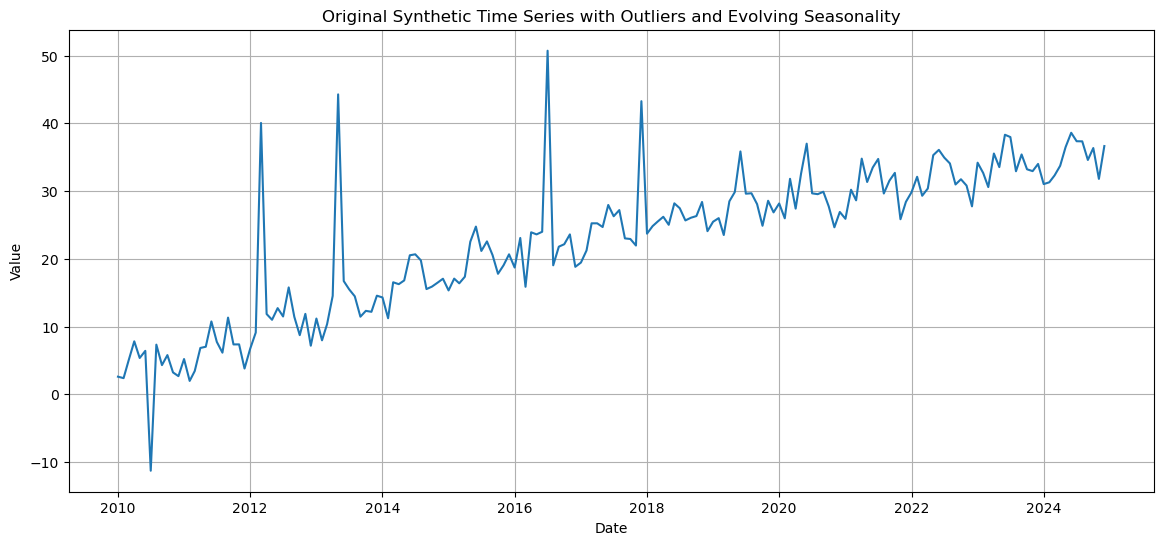

In [34]:
# Combine them for the time series (additive model assumed by default by STL, but it's robust)
time_series = trend + seasonality + residuals

# Create a Pandas Series
data = pd.Series(time_series, index=index)

# Plot the original time series with outliers
plt.figure(figsize=(14, 6))
plt.plot(data)
plt.title('Original Synthetic Time Series with Outliers and Evolving Seasonality')
plt.xlabel('Date')
plt.ylabel('Value')
plt.grid(True)
plt.show()

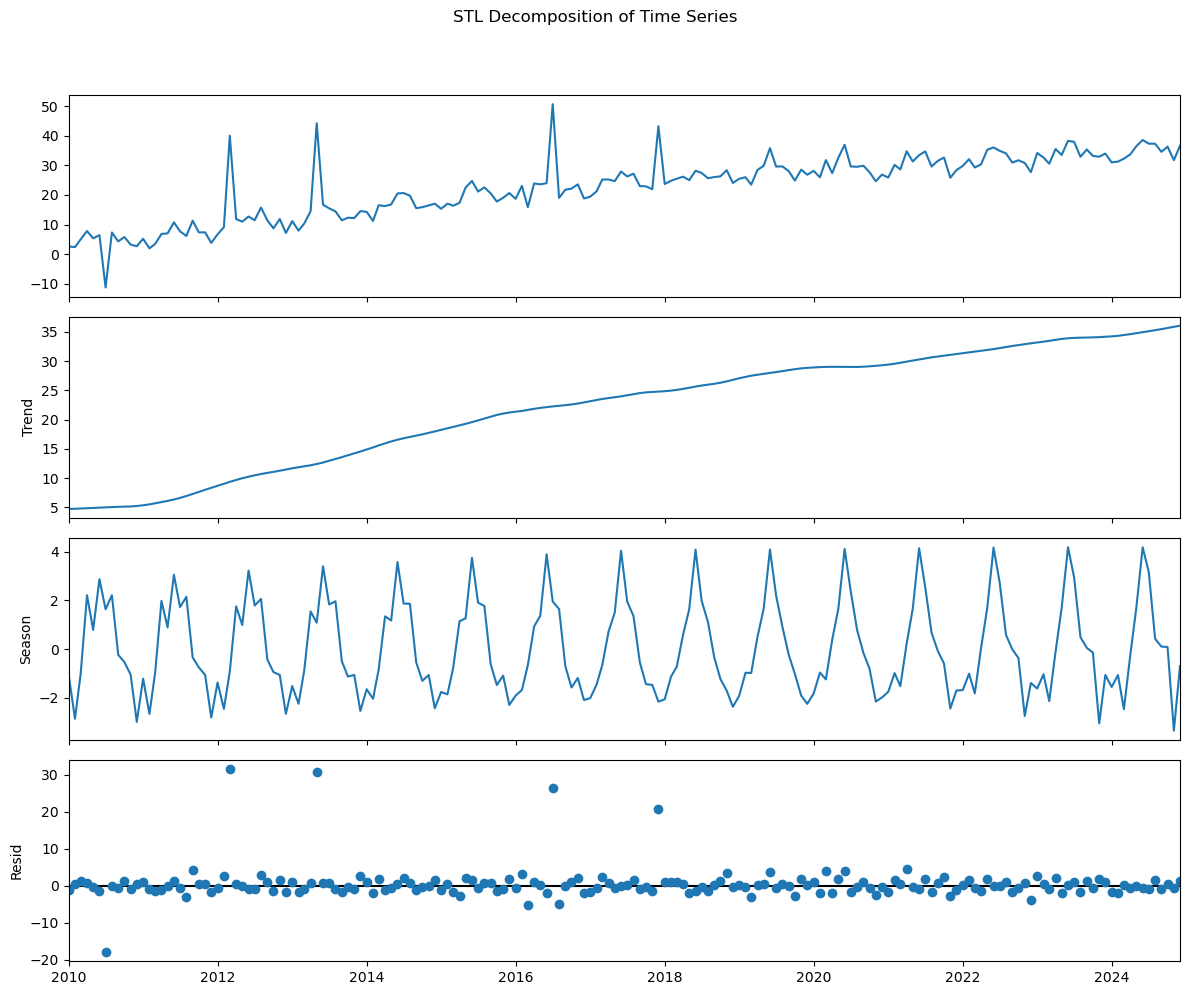


STL Model Components (first 5 values):
Original Data:
 2010-01-01    2.593428
2010-02-01    2.378819
2010-03-01    5.006045
2010-04-01    7.811993
2010-05-01    5.352812
Freq: MS, dtype: float64
Trend Component:
 2010-01-01    4.709758
2010-02-01    4.753697
2010-03-01    4.799099
2010-04-01    4.846892
2010-05-01    4.896912
Freq: MS, Name: trend, dtype: float64
Seasonal Component:
 2010-01-01   -1.048598
2010-02-01   -2.853226
2010-03-01   -1.004144
2010-04-01    2.208994
2010-05-01    0.788004
Freq: MS, Name: season, dtype: float64
Residual Component:
 2010-01-01   -1.067732
2010-02-01    0.478348
2010-03-01    1.211090
2010-04-01    0.756107
2010-05-01   -0.332104
Freq: MS, Name: resid, dtype: float64


In [35]:
# 2. Perform STL Decomposition
# The `period` argument is crucial for seasonality. For monthly data, it's 12.
# `seasonal`: Must be odd. Controls the smoothness of the seasonal component.
#             Smaller values capture more rapidly changing seasonal patterns.
#             Larger values result in smoother seasonal patterns.
# `trend`: Must be odd. Controls the smoothness of the trend component.
#          Often, a default value or something related to the period is used.
# `low_pass`: Must be odd. Controls the smoothness of the low-pass filter used in the trend extraction.
# `robust`: If True, the decomposition is robust to outliers. Highly recommended.

# A common heuristic for seasonal_smoother (seasonal) is a value between 7 and 21 for monthly data.
# For trend_smoother (trend), often a value larger than seasonal_smoother, or
# a multiple of the period is used (e.g., 1.5 * period).

# Let's try some typical values:
stl_result = STL(data, period=12, seasonal=13, trend=21, low_pass=None, robust=True).fit()

# 3. Plot the Decomposed Components
fig = stl_result.plot()
fig.set_size_inches(12, 10)
fig.suptitle('STL Decomposition of Time Series', y=1.02)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# You can access the components individually:
trend_component_stl = stl_result.trend
seasonal_component_stl = stl_result.seasonal
residual_component_stl = stl_result.resid

print("\nSTL Model Components (first 5 values):")
print("Original Data:\n", data.head())
print("Trend Component:\n", trend_component_stl.head())
print("Seasonal Component:\n", seasonal_component_stl.head())
print("Residual Component:\n", residual_component_stl.head())


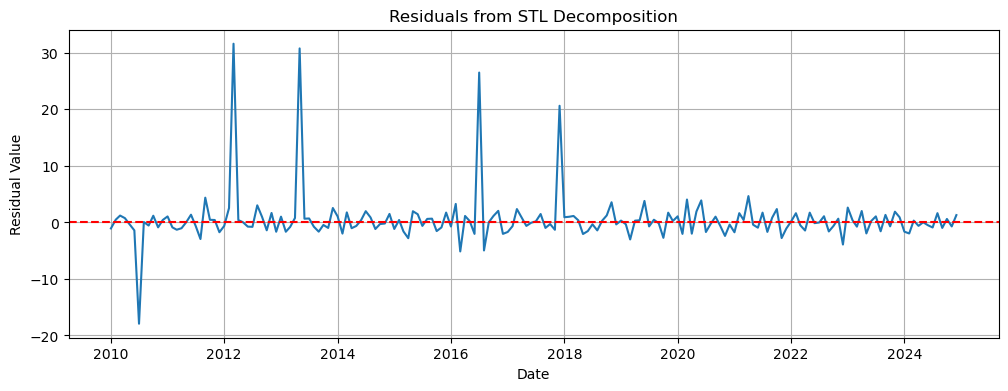


Residuals Summary Statistics:
count    180.000000
mean       0.522861
std        4.610921
min      -17.925420
25%       -0.976093
50%        0.026548
75%        1.078680
max       31.612155
Name: resid, dtype: float64

Potential Outliers in Residuals (absolute value > 9.22):
2010-07-01   -17.925420
2012-03-01    31.612155
2013-05-01    30.781889
2016-07-01    26.510219
2017-12-01    20.633385
Name: resid, dtype: float64


In [36]:
# Plotting the residuals to check for randomness and outliers
plt.figure(figsize=(12, 4))
plt.plot(residual_component_stl)
plt.title('Residuals from STL Decomposition')
plt.xlabel('Date')
plt.ylabel('Residual Value')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Further analysis: Check for summary statistics of residuals
print("\nResiduals Summary Statistics:")
print(residual_component_stl.describe())

# Identifying potential outliers from residuals
# You might consider values beyond 2 or 3 standard deviations as potential outliers
outlier_threshold = 2 * residual_component_stl.std()
potential_outliers = residual_component_stl[np.abs(residual_component_stl) > outlier_threshold]
print(f"\nPotential Outliers in Residuals (absolute value > {outlier_threshold:.2f}):")
print(potential_outliers)

# STL Decomposition - End

# ====================================================

# ---------------------------- Types of Stationarity ----------------------------

# Stationarity - Start

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf # For ACF/PACF plots

# Function to perform and print ADF test results
def adf_test_results(series, name='Series'):
    result = adfuller(series.dropna()) # .dropna() because differencing might introduce NaNs
    print(f'\n--- Augmented Dickey-Fuller Test for {name} ---')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'  {key}: {value:.4f}')
    if result[1] <= 0.05:
        print(f"Conclusion: Reject H0. {name} is likely stationary.")
    else:
        print(f"Conclusion: Fail to reject H0. {name} is likely non-stationary.")

# Function to perform and print KPSS test results
def kpss_test_results(series, name='Series', regression='c'): # 'c' for constant, 'ct' for constant + trend
    result = kpss(series.dropna(), regression=regression)
    print(f'\n--- KPSS Test for {name} (regression={regression}) ---')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[3].items():
        print(f'  {key}: {value:.4f}')
    if result[1] > 0.05:
        print(f"Conclusion: Fail to reject H0. {name} is likely stationary.")
    else:
        print(f"Conclusion: Reject H0. {name} is likely non-stationary.")


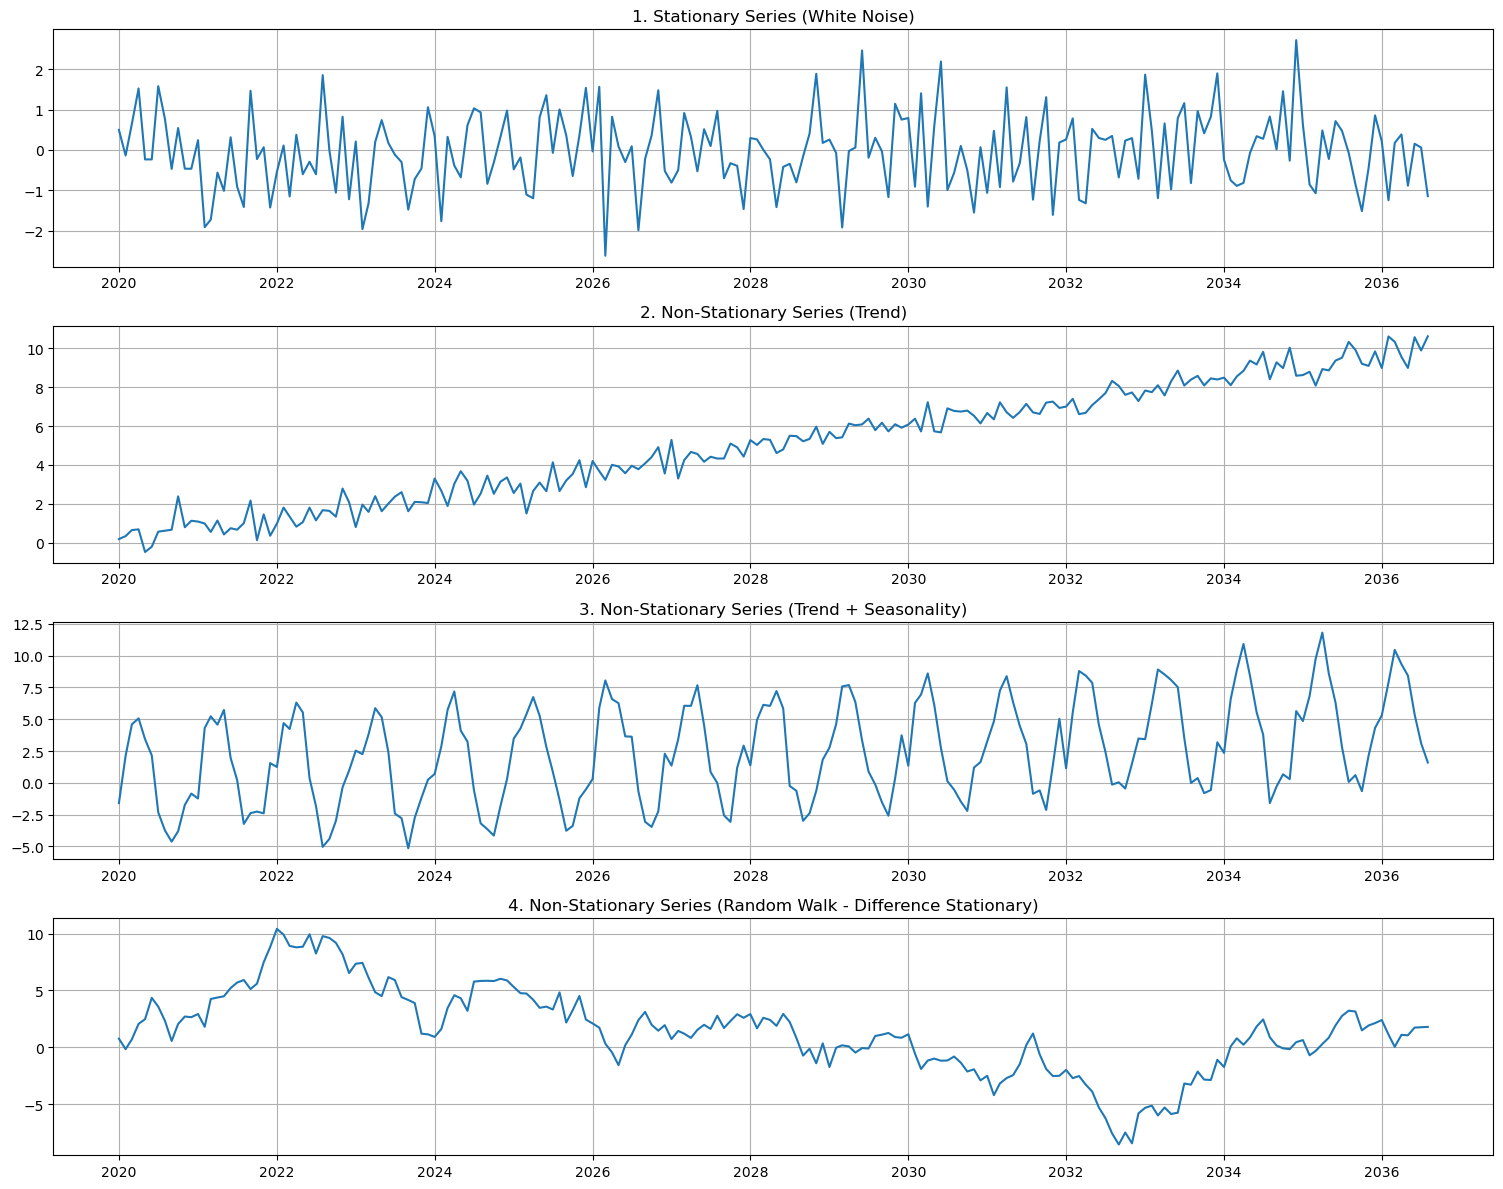

In [47]:
# --- 1. Generate Example Time Series ---
n_points = 200
index = pd.date_range(start='2020-01-01', periods=n_points, freq='MS') # Monthly data

# a) Stationary Series (White Noise)
np.random.seed(42)
stationary_series = pd.Series(np.random.normal(0, 1, n_points), index=index)

# b) Non-Stationary Series (Trend)
non_stationary_trend = pd.Series(np.linspace(0, 10, n_points) + np.random.normal(0, 0.5, n_points), index=index)

# c) Non-Stationary Series (Seasonality + Trend)
seasonality_pattern = np.sin(np.linspace(0, 2 * np.pi, 12)) * 5
non_stationary_seasonal = pd.Series(
    np.tile(seasonality_pattern, n_points // 12 + 1)[:n_points] +
    np.linspace(0, 5, n_points) +
    np.random.normal(0, 1, n_points),
    index=index
)

# d) Non-Stationary Series (Random Walk - Difference Stationary)
random_walk = pd.Series(np.cumsum(np.random.normal(0, 1, n_points)), index=index)


# --- 2. Visualize the Series ---
plt.figure(figsize=(15, 12))

plt.subplot(4, 1, 1)
plt.plot(stationary_series)
plt.title('1. Stationary Series (White Noise)')
plt.grid(True)

plt.subplot(4, 1, 2)
plt.plot(non_stationary_trend)
plt.title('2. Non-Stationary Series (Trend)')
plt.grid(True)

plt.subplot(4, 1, 3)
plt.plot(non_stationary_seasonal)
plt.title('3. Non-Stationary Series (Trend + Seasonality)')
plt.grid(True)

plt.subplot(4, 1, 4)
plt.plot(random_walk)
plt.title('4. Non-Stationary Series (Random Walk - Difference Stationary)')
plt.grid(True)

plt.tight_layout()
plt.show()

In [48]:
# --- 3. Check for Stationarity using Tests ---

# Test Stationary Series
adf_test_results(stationary_series, 'Stationary Series')
kpss_test_results(stationary_series, 'Stationary Series', regression='c') # Test for level stationarity

# Test Non-Stationary (Trend) Series
adf_test_results(non_stationary_trend, 'Non-Stationary (Trend) Series')
kpss_test_results(non_stationary_trend, 'Non-Stationary (Trend) Series', regression='ct') # Test for trend stationarity

# Test Non-Stationary (Trend + Seasonal) Series
adf_test_results(non_stationary_seasonal, 'Non-Stationary (Trend + Seasonal) Series')
kpss_test_results(non_stationary_seasonal, 'Non-Stationary (Trend + Seasonal) Series', regression='ct')

# Test Random Walk (Difference Stationary)
adf_test_results(random_walk, 'Random Walk Series')
kpss_test_results(random_walk, 'Random Walk Series', regression='c')


--- Augmented Dickey-Fuller Test for Stationary Series ---
ADF Statistic: -14.7442
p-value: 0.0000
Critical Values:
  1%: -3.4636
  5%: -2.8762
  10%: -2.5746
Conclusion: Reject H0. Stationary Series is likely stationary.

--- KPSS Test for Stationary Series (regression=c) ---
KPSS Statistic: 0.1797
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Conclusion: Fail to reject H0. Stationary Series is likely stationary.

--- Augmented Dickey-Fuller Test for Non-Stationary (Trend) Series ---
ADF Statistic: 0.8355
p-value: 0.9922
Critical Values:
  1%: -3.4660
  5%: -2.8772
  10%: -2.5751
Conclusion: Fail to reject H0. Non-Stationary (Trend) Series is likely non-stationary.

--- KPSS Test for Non-Stationary (Trend) Series (regression=ct) ---
KPSS Statistic: 0.0667
p-value: 0.1000
Critical Values:
  10%: 0.1190
  5%: 0.1460
  2.5%: 0.1760
  1%: 0.2160
Conclusion: Fail to reject H0. Non-Stationary (Trend) Series is likely stationary.

--- Augmented Dick

C:\Users\white\AppData\Local\Temp\ipykernel_14716\2722060968.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression)
C:\Users\white\AppData\Local\Temp\ipykernel_14716\2722060968.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression)
C:\Users\white\AppData\Local\Temp\ipykernel_14716\2722060968.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression)
C:\Users\white\AppData\Local\Temp\ipykernel_14716\2722060968.py:23: InterpolationWarning: The test statistic is outside of the 

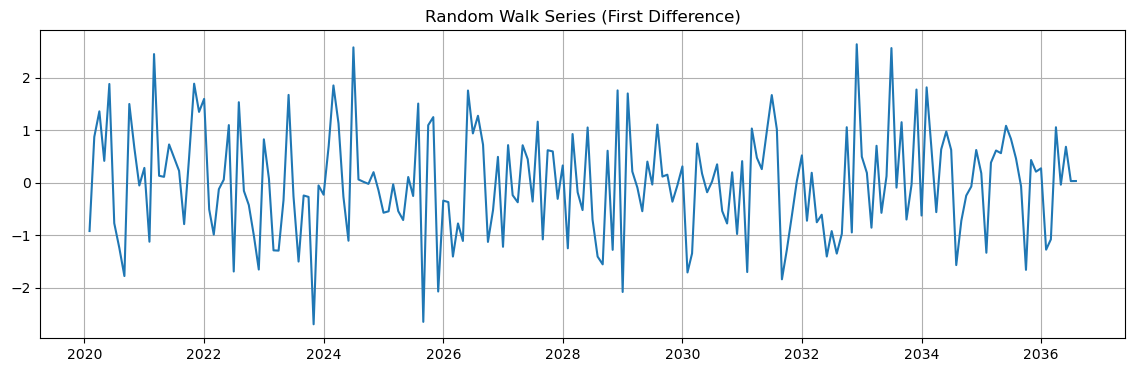


--- Augmented Dickey-Fuller Test for Differenced Random Walk Series ---
ADF Statistic: -14.7468
p-value: 0.0000
Critical Values:
  1%: -3.4638
  5%: -2.8763
  10%: -2.5746
Conclusion: Reject H0. Differenced Random Walk Series is likely stationary.

--- KPSS Test for Differenced Random Walk Series (regression=c) ---
KPSS Statistic: 0.0775
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Conclusion: Fail to reject H0. Differenced Random Walk Series is likely stationary.


C:\Users\white\AppData\Local\Temp\ipykernel_14716\2722060968.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression)


In [50]:
# --- 4. Demonstrate Differencing for Non-Stationary Series ---

# First difference of the random walk
random_walk_diff = random_walk.diff().dropna()

plt.figure(figsize=(14, 4))
plt.plot(random_walk_diff)
plt.title('Random Walk Series (First Difference)')
plt.grid(True)
plt.show()

# Test the differenced random walk for stationarity
adf_test_results(random_walk_diff, 'Differenced Random Walk Series')
kpss_test_results(random_walk_diff, 'Differenced Random Walk Series', regression='c')


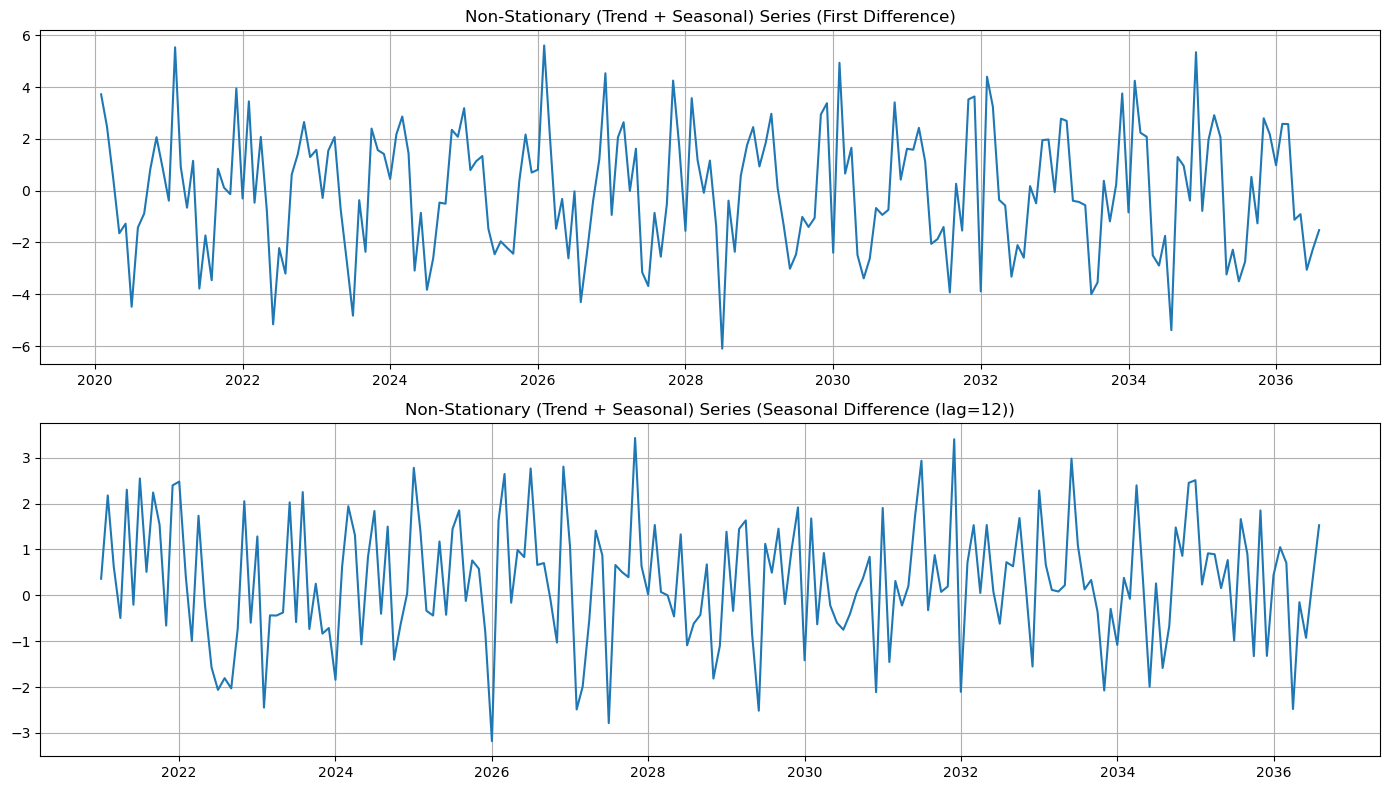


--- Augmented Dickey-Fuller Test for Seasonal Series (First Diff) ---
ADF Statistic: -12.3229
p-value: 0.0000
Critical Values:
  1%: -3.4658
  5%: -2.8771
  10%: -2.5751
Conclusion: Reject H0. Seasonal Series (First Diff) is likely stationary.

--- KPSS Test for Seasonal Series (First Diff) (regression=c) ---
KPSS Statistic: 0.0121
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Conclusion: Fail to reject H0. Seasonal Series (First Diff) is likely stationary.

--- Augmented Dickey-Fuller Test for Seasonal Series (Seasonal Diff) ---
ADF Statistic: -5.3752
p-value: 0.0000
Critical Values:
  1%: -3.4683
  5%: -2.8782
  10%: -2.5757
Conclusion: Reject H0. Seasonal Series (Seasonal Diff) is likely stationary.

--- KPSS Test for Seasonal Series (Seasonal Diff) (regression=c) ---
KPSS Statistic: 0.0363
p-value: 0.1000
Critical Values:
  10%: 0.3470
  5%: 0.4630
  2.5%: 0.5740
  1%: 0.7390
Conclusion: Fail to reject H0. Seasonal Series (Seasonal Diff) i

C:\Users\white\AppData\Local\Temp\ipykernel_14716\2722060968.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression)
C:\Users\white\AppData\Local\Temp\ipykernel_14716\2722060968.py:23: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result = kpss(series.dropna(), regression=regression)


In [51]:
# First difference and seasonal difference for the seasonal series
non_stationary_seasonal_diff1 = non_stationary_seasonal.diff(1).dropna()
non_stationary_seasonal_diff12 = non_stationary_seasonal.diff(12).dropna() # Seasonal differencing

plt.figure(figsize=(14, 8))
plt.subplot(2, 1, 1)
plt.plot(non_stationary_seasonal_diff1)
plt.title('Non-Stationary (Trend + Seasonal) Series (First Difference)')
plt.grid(True)

plt.subplot(2, 1, 2)
plt.plot(non_stationary_seasonal_diff12)
plt.title('Non-Stationary (Trend + Seasonal) Series (Seasonal Difference (lag=12))')
plt.grid(True)
plt.tight_layout()
plt.show()

adf_test_results(non_stationary_seasonal_diff1, 'Seasonal Series (First Diff)')
kpss_test_results(non_stationary_seasonal_diff1, 'Seasonal Series (First Diff)', regression='c')

adf_test_results(non_stationary_seasonal_diff12, 'Seasonal Series (Seasonal Diff)')
kpss_test_results(non_stationary_seasonal_diff12, 'Seasonal Series (Seasonal Diff)', regression='c')


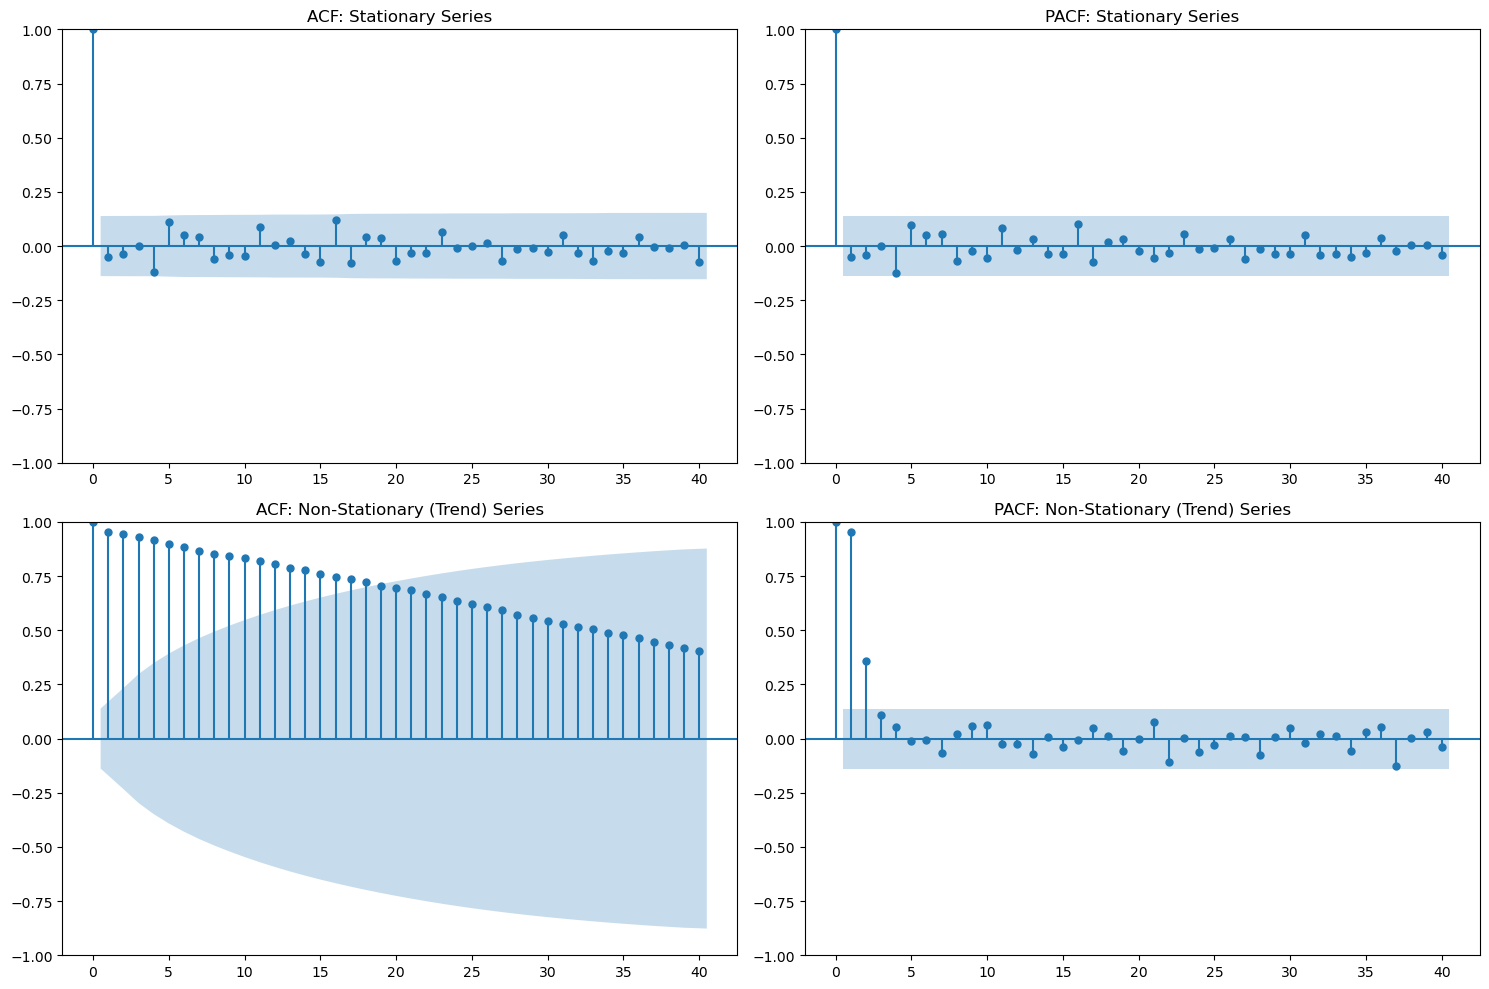

In [52]:
# --- 5. Autocorrelation Plots (ACF/PACF) as Visual Aid for Stationarity ---
# Stationary series ACF should drop quickly
# Non-stationary series ACF decays slowly (persisting correlation)

plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plot_acf(stationary_series, ax=plt.gca(), lags=40, title='ACF: Stationary Series')
plt.subplot(2, 2, 2)
plot_pacf(stationary_series, ax=plt.gca(), lags=40, title='PACF: Stationary Series')

plt.subplot(2, 2, 3)
plot_acf(non_stationary_trend, ax=plt.gca(), lags=40, title='ACF: Non-Stationary (Trend) Series')
plt.subplot(2, 2, 4)
plot_pacf(non_stationary_trend, ax=plt.gca(), lags=40, title='PACF: Non-Stationary (Trend) Series')

plt.tight_layout()
plt.show()

# Stationarity - End